<a href="https://colab.research.google.com/github/fadlisalmaencg-a11y/DS-2025/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nalisha_health_insurance_charges_dataset_path = kagglehub.dataset_download('nalisha/health-insurance-charges-dataset')

print('Data source import complete.')


100%|██████████| 16.0k/16.0k [00:00<00:00, 9.45MB/s]

Extracting files...
Data source import complete.


# Introductions

## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [4]:
from google.colab import files
uploaded = files.upload()   # Choisis ton ZIP


Saving archive.zip to archive.zip


In [6]:
import zipfile

zip_file = "archive.zip"  # NOM EXACT du fichier ZIP
with zipfile.ZipFile(zip_file, 'r') as z:
    z.extractall()   # extrait tous les fichiers ici


In [7]:
import os
os.listdir()


['.config', 'insurance.csv', 'archive.zip', 'sample_data']

In [8]:
import pandas as pd
df = pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.92400
1,18.0,male,33.770,1.0,no,southeast,1725.55230
2,28.0,male,33.000,3.0,no,southeast,4449.46200
3,33.0,male,22.705,0.0,no,northwest,21984.47061
4,32.0,male,28.880,0.0,no,northwest,3866.85520


## Data cleaning

In [9]:
df.isna().sum(),df.duplicated().sum()

(age         1
 sex         0
 bmi         1
 children    1
 smoker      0
 region      0
 charges     0
 dtype: int64,
 np.int64(1))

In [10]:
df = df.drop_duplicates()
df = df.dropna()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


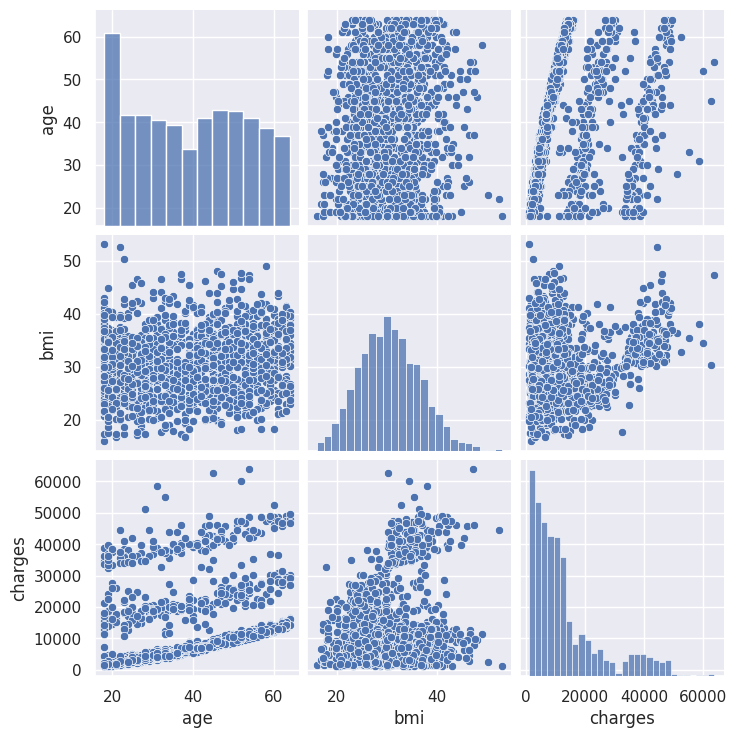

In [11]:
cool_columns = ['age', 'bmi', 'charges']
sns.pairplot(df[cool_columns], size = 2.5)

<Axes: xlabel='region', ylabel='charges'>

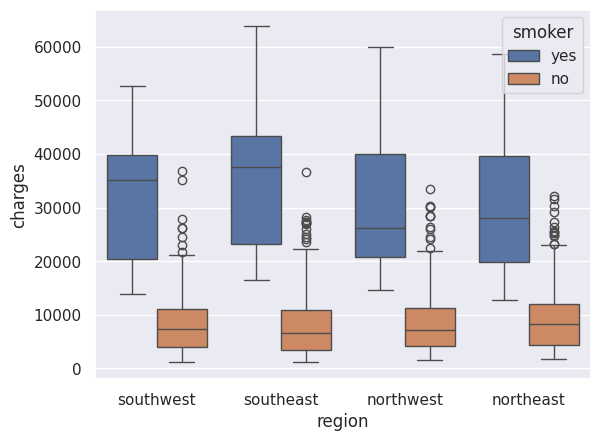

In [12]:
sns.boxplot(data=df, x='region', y='charges', hue='smoker')

<Axes: >

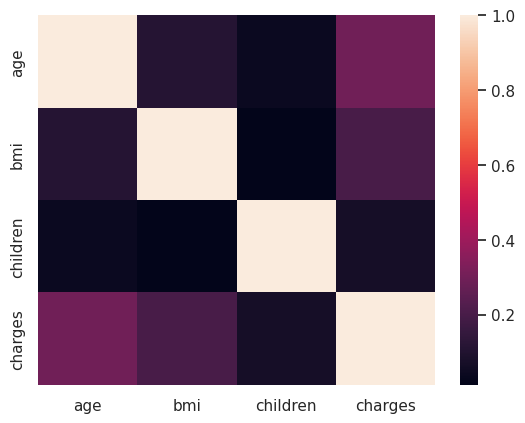

In [13]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr)

## Preprocessing

In [14]:
from sklearn.preprocessing import StandardScaler
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['region'] = df['region'].astype('category').cat.codes
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,0,27.900,0.0,1,3,16884.92400
1,18.0,1,33.770,1.0,0,2,1725.55230
2,28.0,1,33.000,3.0,0,2,4449.46200
3,33.0,1,22.705,0.0,0,1,21984.47061
4,32.0,1,28.880,0.0,0,1,3866.85520


## Modeling

- Do people with similar charges share similar BMI and smoking behavior?

In [15]:
from sklearn.cluster import KMeans
features_q1 = df[['charges', 'bmi', 'smoker', 'children']]
scaler = StandardScaler()
scaled_q1 = scaler.fit_transform(features_q1)
kmeans_q1 = KMeans(n_clusters=3, random_state=42)
df['cluster_q1'] = kmeans_q1.fit_predict(scaled_q1)
cluster_summary_q1 = df.groupby('cluster_q1')[['charges', 'bmi', 'smoker', 'children']].mean()
cluster_summary_q1

,charges,bmi,smoker,children
cluster_q1,,,,
0,7851.378799,30.557830,0.000000,0.365786
1,9666.337694,30.816035,0.002915,2.629738
2,32108.819491,30.760092,1.000000,1.102941


Text(0.5, 1.0, 'Clusters for Q1: Charges vs BMI')

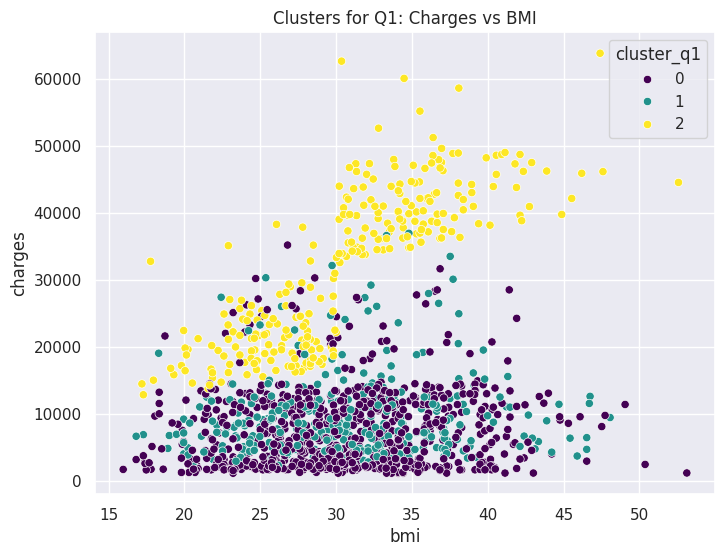

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    hue='cluster_q1',
    palette='viridis'
)
plt.title("Clusters for Q1: Charges vs BMI")


Text(0.5, 0.92, 'Clusters for BMI, Smokers vs Charges')

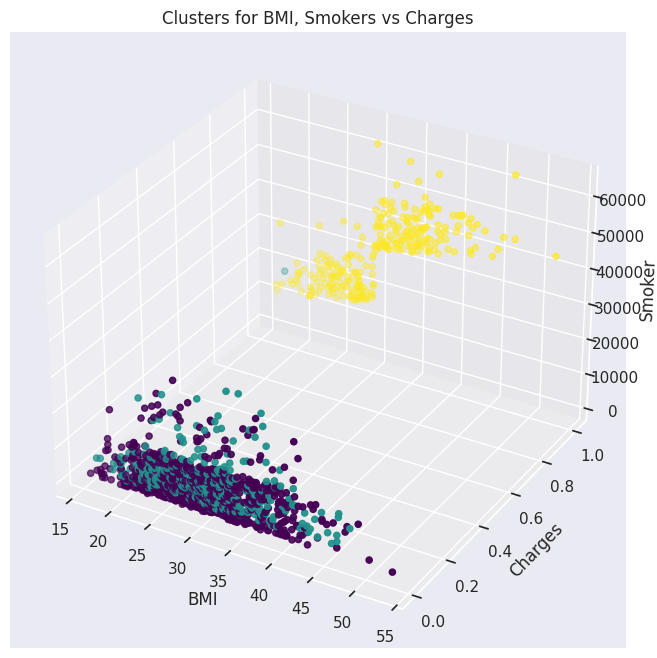

In [17]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['bmi'],
    df['smoker'],
    df['charges'],
    c=df['cluster_q1'],
    cmap='viridis'
)
ax.set_xlabel('BMI')
ax.set_ylabel('Charges')
ax.set_zlabel('Smoker')
plt.title("Clusters for BMI, Smokers vs Charges")

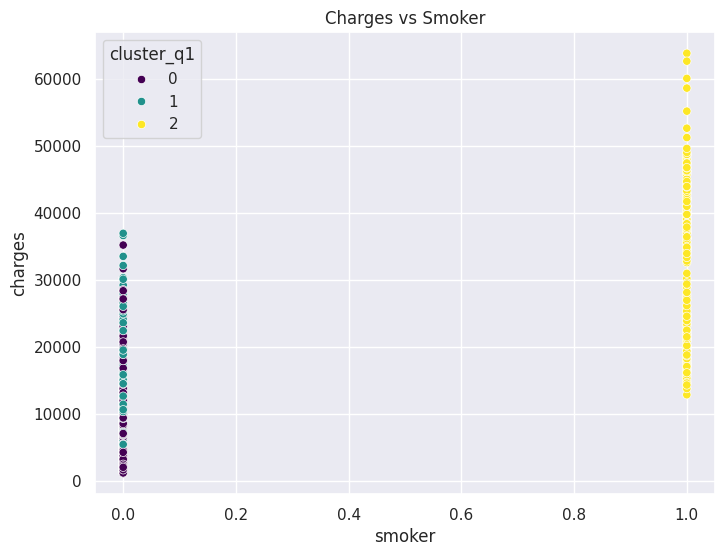

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='smoker',
    y='charges',
    hue='cluster_q1',
    palette='viridis'
)
plt.title("Charges vs Smoker")
plt.show()


- Do people with similar charges share similar BMI and smoking behavior?

In [19]:
features = df[['age', 'bmi', 'smoker', 'charges']]
scaled_q2 = scaler.fit_transform(features)
kmeans_q2 = KMeans(n_clusters=3)
df['cluster_q2'] = kmeans_q2.fit_predict(scaled_q2)

cluster_summary = df.groupby('cluster_q2')[['age', 'bmi', 'smoker', 'charges']].mean()
print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
                  age        bmi  smoker       charges
cluster_q2                                            
0           51.562380  32.231084     0.0  11888.630032
1           27.666667  29.130157     0.0   5088.325332
2           38.432234  30.714451     1.0  32060.887039


In [20]:
features = df[['age', 'bmi', 'smoker', 'charges']]
scaled_q2 = scaler.fit_transform(features)
kmeans_q2 = KMeans(n_clusters=3)
df['cluster_q2'] = kmeans_q2.fit_predict(scaled_q2)

cluster_summary = df.groupby('cluster_q2')[['age', 'bmi', 'smoker', 'charges']].mean()
print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
                  age        bmi  smoker       charges
cluster_q2                                            
0           27.666667  29.130157     0.0   5088.325332
1           51.562380  32.231084     0.0  11888.630032
2           38.432234  30.714451     1.0  32060.887039


In [21]:
high_cost_cluster = cluster_summary['charges'].idxmax()
print("\nHigh-cost cluster:", high_cost_cluster)
print(cluster_summary.loc[high_cost_cluster])


High-cost cluster: 2
age           38.432234
bmi           30.714451
smoker         1.000000
charges    32060.887039
Name: 2, dtype: float64


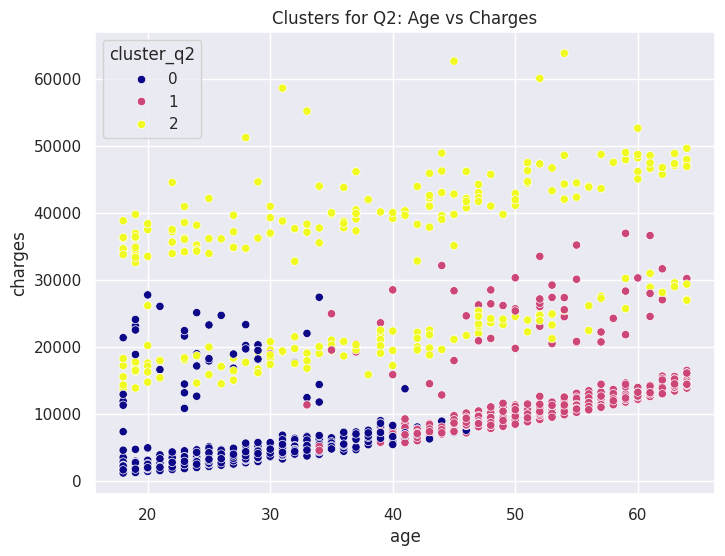

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    hue='cluster_q2',
    palette='plasma'
)
plt.title("Clusters for Q2: Age vs Charges")
plt.show()


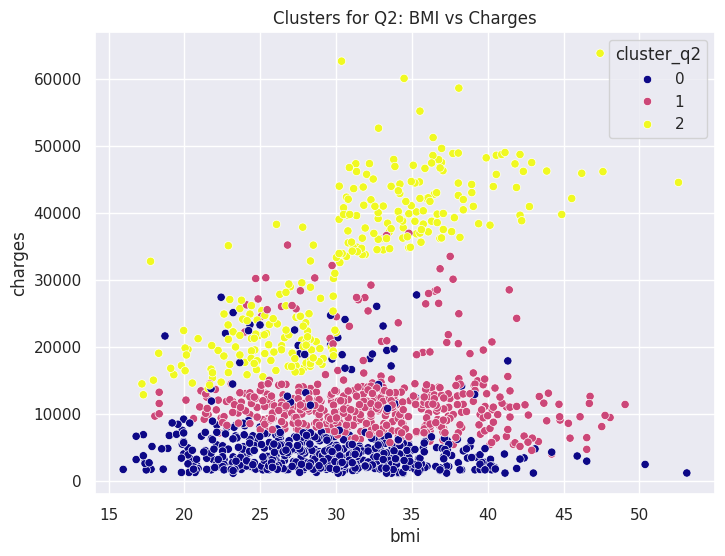

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    hue='cluster_q2',
    palette='plasma'
)
plt.title("Clusters for Q2: BMI vs Charges")
plt.show()


## Impact

By Clustering age and bmi, we can clearly see that the highest cost cluster group is smokers with a BMI of 30. We can use this data as a population to avoid insurance premiums. By not smoking and keeping our BMI down, We can avoid higher premiums. By clustering, we can see the patterns that lead to higher costs.

## References

- https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/
- https://www.geeksforgeeks.org/machine-learning/ml-implementation-of-knn-classifier-using-sklearn/
- https://www.geeksforgeeks.org/machine-learning/clustering-in-machine-learning/
- https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/
- https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html